In [1]:
#Phase 1: Data Collection and Exploratory Data Analysis (EDA)
#Step 1 - Data Import and Preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
# Load dataset
df = pd.read_csv("Food_Delivery_Time_Prediction.csv")
df.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4,Medium,Afternoon,Car,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2,Medium,Evening,Bike,3.2,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6,Low,Night,Bike,3.5,2.8,32.38,619.81,2.34


In [3]:
df.isnull().sum()



Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [4]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [5]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

In [6]:
scaler = StandardScaler()

num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = scaler.fit_transform(df[num_cols])

In [7]:
#Step 2 - Exploratory Data Analysis (EDA)
df.describe()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
count,200.000000,2.000000e+02,200.000000,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02,2.000000e+02
mean,0.000000,-1.998401e-17,0.000000,-1.643130e-16,-1.776357e-17,9.769963e-17,4.440892e-18,7.105427e-17,-7.993606e-17,7.549517e-17,3.463896e-16,4.529710e-16,3.730349e-16,-2.042810e-16,-4.440892e-18
std,1.002509,1.002509e+00,1.002509,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00,1.002509e+00
min,-1.723412,-1.723412e+00,-1.723412,-1.608593e+00,-1.426220e+00,-1.415221e+00,-1.552139e+00,-1.323979e+00,-1.199112e+00,-1.193475e+00,-1.766103e+00,-1.562593e+00,-1.857269e+00,-1.688954e+00,-1.549315e+00
25%,-0.861706,-8.617060e-01,-0.861706,-7.924313e-01,-5.119763e-01,-1.415221e+00,-8.217208e-01,-1.323979e+00,-1.199112e+00,-1.193475e+00,-7.679018e-01,-8.434984e-01,-7.896704e-01,-9.013569e-01,-8.540689e-01
50%,0.000000,0.000000e+00,0.000000,-1.806765e-01,4.022671e-01,-1.108698e-01,-9.130231e-02,-5.701343e-02,-3.108809e-01,4.328664e-02,8.769909e-02,1.941556e-02,7.662482e-02,-1.925947e-02,3.118490e-02
75%,0.861706,8.617060e-01,0.861706,7.325599e-01,1.316510e+00,1.193481e+00,1.004325e+00,1.209952e+00,5.773503e-01,1.280048e+00,8.006998e-01,8.823295e-01,8.789834e-01,9.076026e-01,8.067529e-01
max,1.723412,1.723412e+00,1.723412,1.963762e+00,1.316510e+00,1.193481e+00,1.734744e+00,1.209952e+00,1.465581e+00,1.280048e+00,1.798901e+00,1.889062e+00,1.652608e+00,1.737826e+00,1.813813e+00


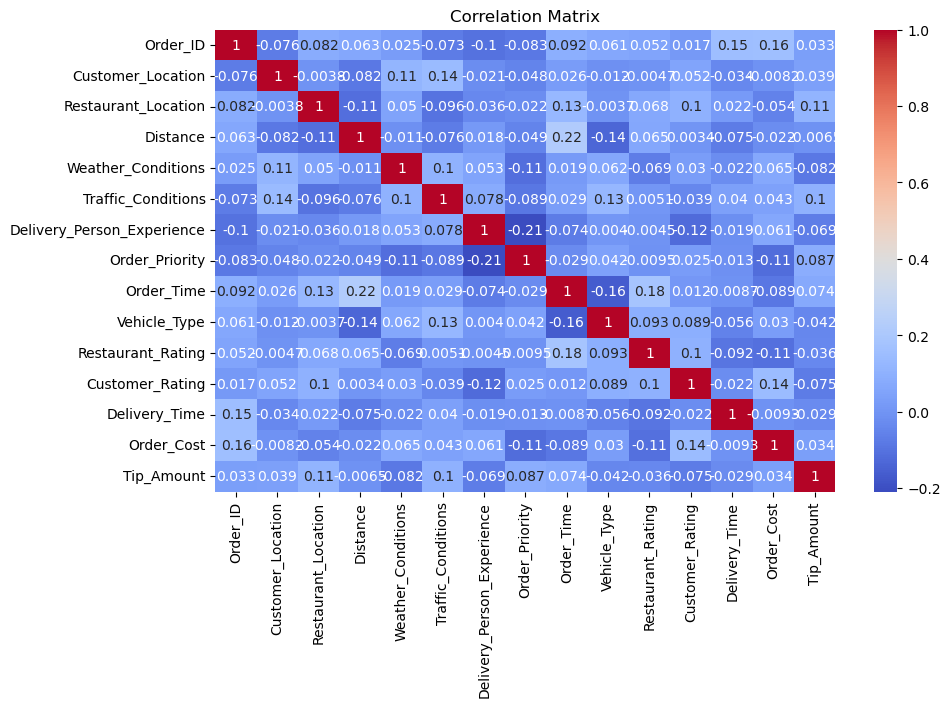

In [8]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

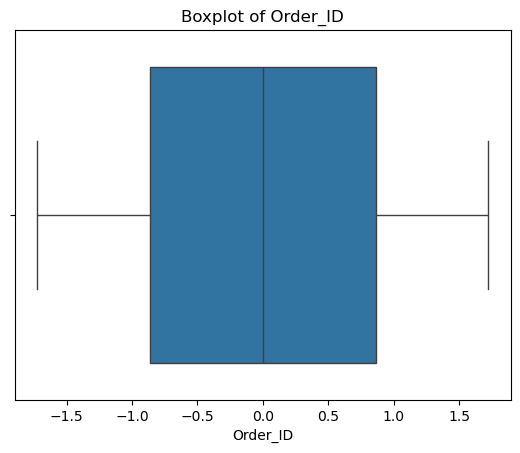

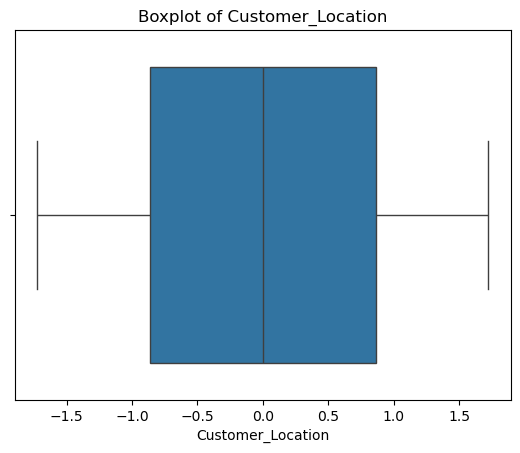

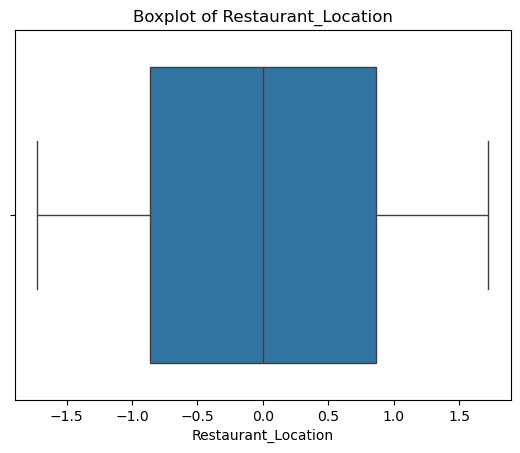

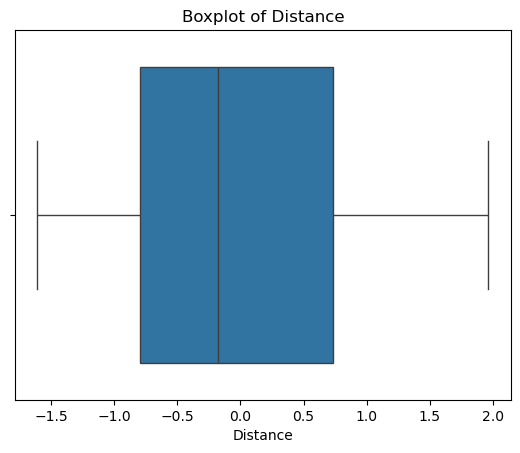

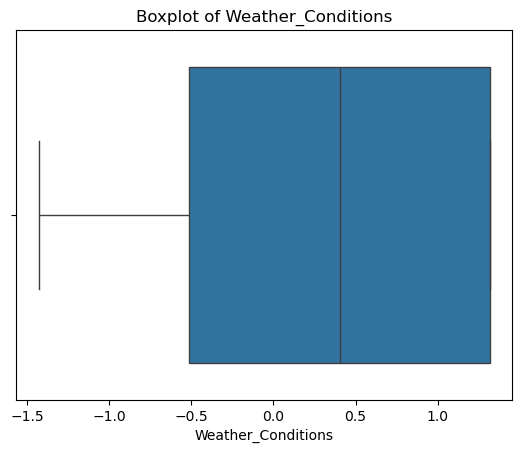

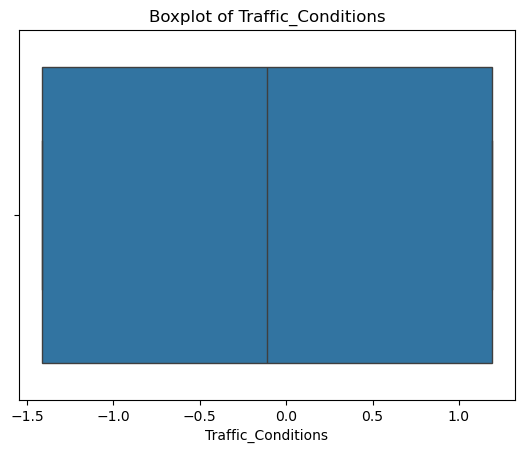

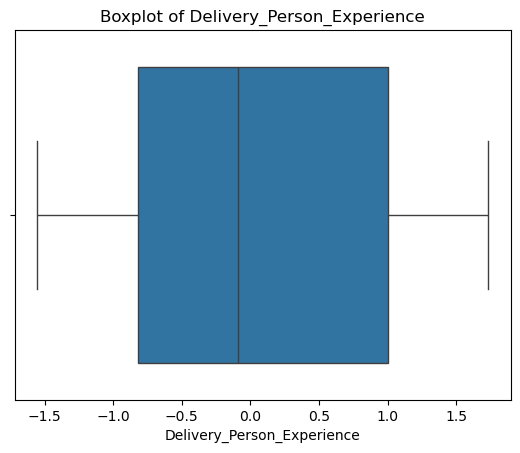

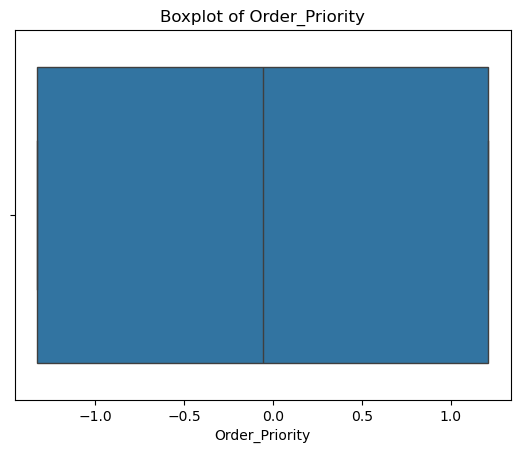

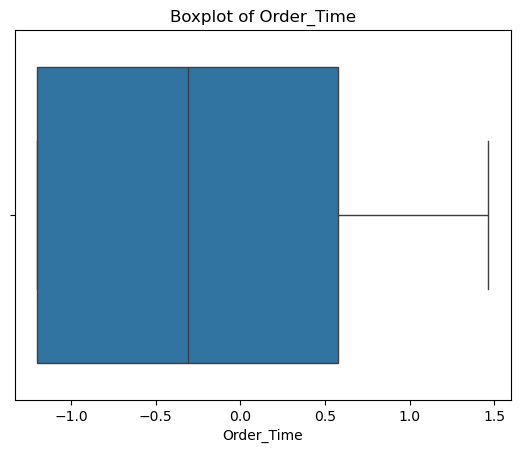

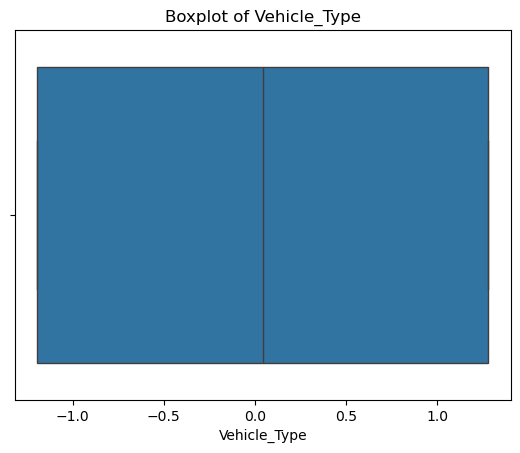

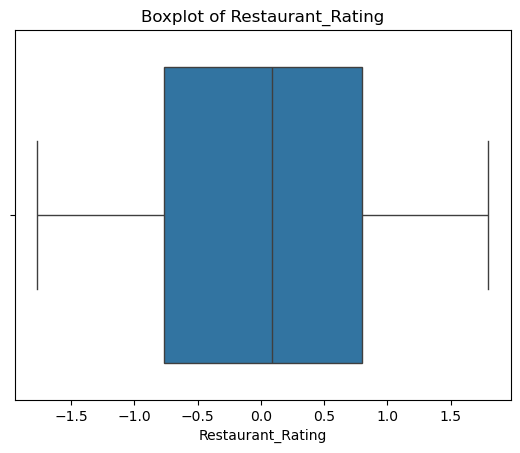

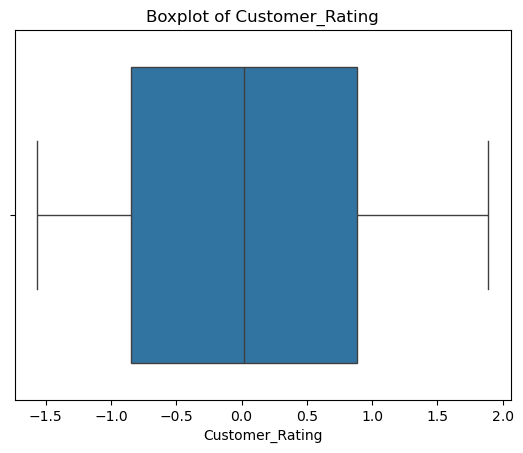

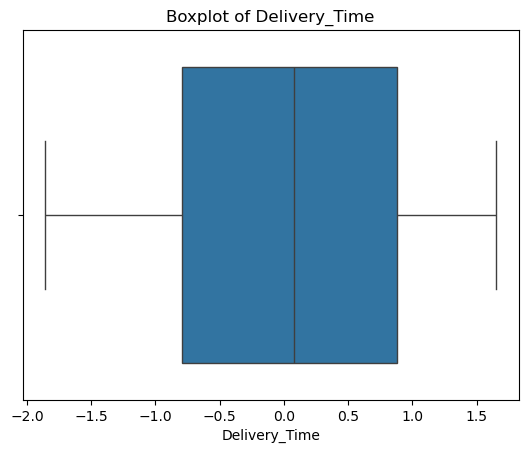

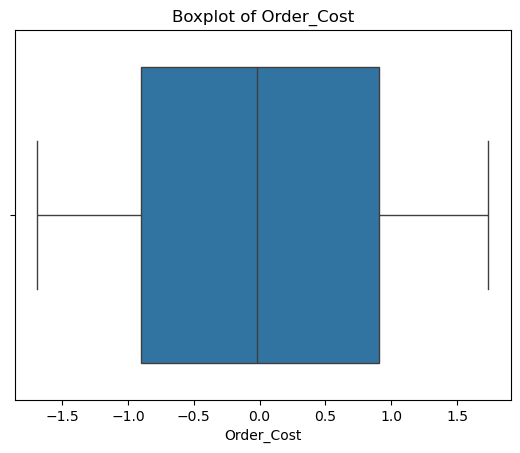

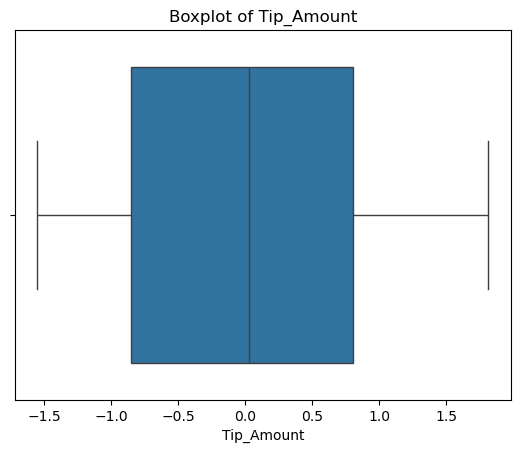

In [9]:
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [10]:
def haversine(loc1, loc2):
    """
    Calculates the great-circle distance between two points on Earth.
    """
    try:
        lat1, lon1 = map(float, loc1.split(','))
        lat2, lon2 = map(float, loc2.split(','))
        
        # Convert to radians
        lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
        
        dlon = lon2 - lon1
        dlat = lat2 - lat1
        a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
        c = 2 * asin(sqrt(a))
        r = 6371 # Radius of Earth in KM
        return c * r
    except:
        return 0

# Apply Haversine
df['Calculated_Distance'] = df.apply(lambda x: haversine(x['Customer_Location'], x['Restaurant_Location']), axis=1)
threshold = df['Delivery_Time'].median()
df['Delivery_Status'] = (df['Delivery_Time'] > threshold).astype(int)

In [11]:
if 'Hour' in df.columns:
    df['Rush_Hour'] = df['Hour'].apply(lambda x: 1 if 7<=x<=10 or 17<=x<=20 else 0)

In [12]:
#Phase 2: Predictive Modeling

X = df.drop("Delivery_Time", axis=1)
y = df["Delivery_Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
y_pred = lr.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.37243620871221417
MAE: 0.5361540264518119
R2 Score: 0.6434577102823247


In [15]:
df['Delivery_Status'] = df['Delivery_Time'].apply(
    lambda x: 1 if x > df['Delivery_Time'].mean() else 0
)

In [16]:
X = df.drop(['Delivery_Time', 'Delivery_Status'], axis=1)
y = df['Delivery_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.6
Precision: 0.6363636363636364
Recall: 0.6363636363636364
F1 Score: 0.6363636363636364


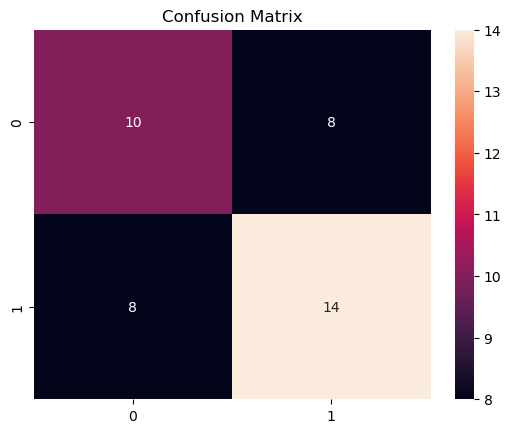

In [18]:
#Phase 3: Reporting and Insights
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

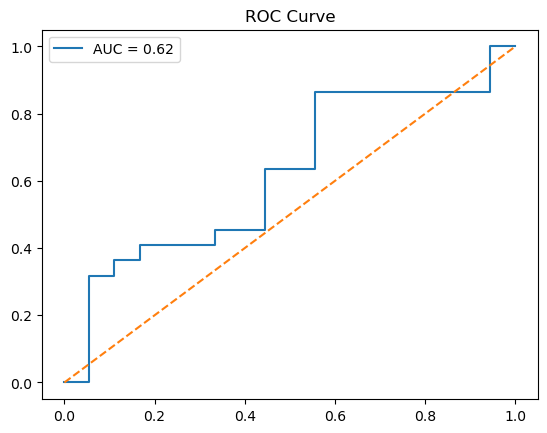

In [19]:
y_prob = log_model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

In [20]:
print("Insights:")
print("- Distance and traffic conditions significantly affect delivery time.")
print("- Peak (rush) hours lead to higher delays.")
print("- Logistic model helps classify delayed deliveries.")
print("- Optimization of routes can reduce delivery time.")
print("- More staff during peak hours can improve efficiency.")


Insights:
- Distance and traffic conditions significantly affect delivery time.
- Peak (rush) hours lead to higher delays.
- Logistic model helps classify delayed deliveries.
- Optimization of routes can reduce delivery time.
- More staff during peak hours can improve efficiency.
